# 详细分析模型检测结果

这个notebook用于详细分析MTAD-GAT模型的异常检测结果，特别是可视化模型学到了什么内容.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import json
from datetime import datetime

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

In [10]:
def find_model_path(result_path, model_id):
    """
    查找模型路径
    """
    # 检查是否是通用模型路径
    universal_model_path = os.path.join(result_path, 'universal_model')
    if os.path.exists(universal_model_path):
        result_path = universal_model_path
        print(f"检测到通用模型路径，更新为: {result_path}")

    if model_id is None:
        dir_content = os.listdir(result_path)
        subfolders = [subf for subf in dir_content if os.path.isdir(os.path.join(result_path, subf)) and subf != "logs"]
        # 过滤出时间戳格式的目录
        date_times = []
        for subf in subfolders:
            try:
                dt = datetime.strptime(subf, '%d%m%Y_%H%M%S')
                date_times.append(dt)
            except ValueError:
                continue
        if not date_times:
            raise Exception(f"在 {result_path} 中未找到有效的时间戳目录")
        date_times.sort()
        model_datetime = date_times[-1]
        model_id = model_datetime.strftime('%d%m%Y_%H%M%S')

    if str(model_id).startswith('-'):
        # 处理相对ID（如-1, -2等）
        dir_content = os.listdir(result_path)
        subfolders = [subf for subf in dir_content if os.path.isdir(os.path.join(result_path, subf)) and subf != "logs"]
        date_times = []
        datetime_folders = {}
        for subf in subfolders:
            try:
                dt = datetime.strptime(subf, '%d%m%Y_%H%M%S')
                date_times.append(dt)
                datetime_folders[dt] = subf
            except ValueError:
                continue
        if not date_times:
            raise Exception(f"在 {result_path} 中未找到有效的时间戳目录")
        date_times.sort()
        index = int(model_id)
        model_datetime = date_times[index]
        model_id = datetime_folders[model_datetime]

    model_path = os.path.join(result_path, model_id)
    print(f"使用模型路径: {model_path}")
    return model_path

In [11]:
def detailed_visualize(test_output, threshold, confidence_level, entity_name, anomaly_scores, anomalies):
    """
    详细可视化模型学到的内容
    """
    # 创建图形
    fig = plt.figure(figsize=(20, 15))
    
    # 时间轴
    if 'timestamp' in test_output.columns:
        x_axis = test_output['timestamp']
        x_label = '时间戳'
    else:
        x_axis = range(len(anomaly_scores))
        x_label = '时间点'

    # 子图1: 异常分数
    ax1 = plt.subplot(3, 2, 1)
    ax1.plot(x_axis, anomaly_scores, 'b-', linewidth=1, label='异常分数')
    ax1.axhline(y=threshold, color='r', linestyle='--', linewidth=1,
                label=f'{confidence_level * 100:.1f}% 置信区间阈值 ({threshold:.4f})')

    # 标记异常点
    if len(anomalies) > 0:
        ax1.scatter([x_axis[i] for i in anomalies], [anomaly_scores[i] for i in anomalies],
                    color='red', s=20, label=f'检测到的异常点 ({len(anomalies)})', zorder=5)

    ax1.set_xlabel(x_label)
    ax1.set_ylabel('异常分数')
    ax1.set_title(f'实体 {entity_name} 的异常分数')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 子图2: 异常点分布直方图
    ax2 = plt.subplot(3, 2, 2)
    ax2.hist(anomaly_scores, bins=50, alpha=0.7, color='blue', edgecolor='black')
    ax2.axvline(x=threshold, color='r', linestyle='--', linewidth=2,
                label=f'{confidence_level * 100:.1f}% 置信区间阈值 ({threshold:.4f})')

    if len(anomalies) > 0:
        ax2.hist([anomaly_scores[i] for i in anomalies], bins=30, alpha=0.7, color='red',
                 label=f'检测到的异常点 ({len(anomalies)})')

    ax2.set_xlabel('异常分数')
    ax2.set_ylabel('频率')
    ax2.set_title(f'实体 {entity_name} 的异常分数分布')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 子图3: 预测值、真实值和重构值对比
    ax3 = plt.subplot(3, 2, (3, 4))
    if 'True_0' in test_output.columns and 'Forecast_0' in test_output.columns:
        true_values = test_output['True_0'].values
        forecast_values = test_output['Forecast_0'].values
        
        ax3.plot(x_axis, true_values, 'g-', linewidth=1, label='真实值')
        ax3.plot(x_axis, forecast_values, 'b-', linewidth=1, label='预测值')
        
        # 如果存在重构值也一并绘制
        if 'Recon_0' in test_output.columns:
            recon_values = test_output['Recon_0'].values
            ax3.plot(x_axis, recon_values, 'm-', linewidth=1, label='重构值')
        
        # 标记异常点
        if len(anomalies) > 0:
            ax3.scatter([x_axis[i] for i in anomalies], [true_values[i] for i in anomalies],
                        color='red', s=20, label=f'异常点 ({len(anomalies)})', zorder=5)
        
        ax3.set_xlabel(x_label)
        ax3.set_ylabel('值')
        ax3.set_title(f'实体 {entity_name} 的预测值、真实值和重构值对比')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
    else:
        ax3.text(0.5, 0.5, '无预测值数据可显示', ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title(f'实体 {entity_name} 的时间序列数据')

    # 子图4: 预测误差和重构误差
    ax4 = plt.subplot(3, 2, 5)
    if 'True_0' in test_output.columns and 'Forecast_0' in test_output.columns:
        true_values = test_output['True_0'].values
        forecast_values = test_output['Forecast_0'].values
        forecast_errors = np.abs(true_values - forecast_values)
        
        ax4.plot(x_axis, forecast_errors, 'b-', linewidth=1, label='预测误差 |真实-预测|')
        
        # 如果存在重构值也计算重构误差
        if 'Recon_0' in test_output.columns:
            recon_values = test_output['Recon_0'].values
            recon_errors = np.abs(true_values - recon_values)
            ax4.plot(x_axis, recon_errors, 'm-', linewidth=1, label='重构误差 |真实-重构|')
        
        # 标记异常点
        if len(anomalies) > 0:
            ax4.scatter([x_axis[i] for i in anomalies], [forecast_errors[i] for i in anomalies],
                        color='red', s=20, label=f'异常点 ({len(anomalies)})', zorder=5)
        
        ax4.set_xlabel(x_label)
        ax4.set_ylabel('误差')
        ax4.set_title(f'实体 {entity_name} 的预测误差和重构误差')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, '无误差数据可显示', ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title(f'实体 {entity_name} 的误差分析')

    # 子图5: 异常分数与真实值的关系
    ax5 = plt.subplot(3, 2, 6)
    if 'True_0' in test_output.columns:
        true_values = test_output['True_0'].values
        
        ax5.scatter(true_values, anomaly_scores, alpha=0.5, s=1, label='数据点')
        
        # 标记异常点
        if len(anomalies) > 0:
            ax5.scatter([true_values[i] for i in anomalies], [anomaly_scores[i] for i in anomalies],
                        color='red', s=20, label=f'异常点 ({len(anomalies)})', zorder=5)
        
        ax5.set_xlabel('真实值')
        ax5.set_ylabel('异常分数')
        ax5.set_title(f'实体 {entity_name} 异常分数与真实值的关系')
        ax5.legend()
        ax5.grid(True, alpha=0.3)
    else:
        ax5.text(0.5, 0.5, '无数据可显示', ha='center', va='center', transform=ax5.transAxes)
        ax5.set_title(f'实体 {entity_name} 的相关性分析')

    plt.tight_layout()
    plt.show()

In [12]:
def analyze_entity_detailed(entity_path, confidence_level, entity_name):
    """
    详细分析单个实体的结果
    """
    # 加载测试输出
    try:
        test_output = pd.read_pickle(os.path.join(entity_path, "test_output.pkl"))
    except FileNotFoundError:
        print(f"在 {entity_path} 中未找到 test_output.pkl 文件")
        return

    # 获取异常分数
    if 'A_Score_Global' in test_output.columns:
        anomaly_scores = test_output['A_Score_Global'].values
    else:
        print("未找到全局异常分数 'A_Score_Global'")
        return

    print(f"异常分数统计:")
    print(f"  最小值: {np.min(anomaly_scores):.6f}")
    print(f"  最大值: {np.max(anomaly_scores):.6f}")
    print(f"  平均值: {np.mean(anomaly_scores):.6f}")
    print(f"  中位数: {np.median(anomaly_scores):.6f}")
    print(f"  标准差: {np.std(anomaly_scores):.6f}")

    # 计算指定置信区间的阈值
    threshold = np.percentile(anomaly_scores, confidence_level * 100)
    print(f"\n{confidence_level * 100:.1f}% 置信区间阈值: {threshold:.6f}")

    # 检测异常点
    anomalies = np.where(anomaly_scores >= threshold)[0]
    print(f"检测到的异常点数量: {len(anomalies)}")
    if len(anomalies) > 0:
        print(f"异常点位置: {anomalies.tolist()}")

    # 尝试加载Epsilon方法的阈值
    try:
        with open(os.path.join(entity_path, "summary.txt"), "r") as f:
            summary = json.load(f)
            epsilon_threshold = summary.get("epsilon_result", {}).get("threshold", None)
            if epsilon_threshold:
                print(f"Epsilon方法阈值: {epsilon_threshold:.6f}")
                epsilon_anomalies = np.where(anomaly_scores >= epsilon_threshold)[0]
                print(f"Epsilon方法检测到的异常点数量: {len(epsilon_anomalies)}")
    except FileNotFoundError:
        print("未找到 summary.txt 文件")

    # 详细可视化
    detailed_visualize(test_output, threshold, confidence_level, entity_name, anomaly_scores, anomalies)

    # 打印详细信息
    print(f"\n实体 {entity_name} 的详细分析:")
    print("-" * 40)

    # 显示前10个最高异常分数的时间点
    top_anomalies = np.argsort(anomaly_scores)[-10:][::-1]
    print("前10个最高异常分数的时间点:")
    for i, idx in enumerate(top_anomalies):
        if 'timestamp' in test_output.columns:
            ts = test_output.iloc[idx]['timestamp']
            print(f"  {i + 1:2d}. 时间戳: {ts}, 位置: {idx:4d}, 分数: {anomaly_scores[idx]:.6f}")
        else:
            print(f"  {i + 1:2d}. 位置: {idx:4d}, 分数: {anomaly_scores[idx]:.6f}")

In [13]:
def detailed_analysis(result_path, confidence_level=0.95, model_id='-1'):
    """
    详细分析异常检测结果

    Parameters:
    result_path: 结果路径
    confidence_level: 置信区间 (例如 0.95)
    model_id: 模型ID
    """

    # 查找模型路径
    save_path = find_model_path(result_path, model_id)

    # 对于通用模型，需要处理所有实体
    if 'universal_model' in save_path:
        entity_dirs = [d for d in os.listdir(save_path)
                       if os.path.isdir(os.path.join(save_path, d)) and d.isdigit()]
        cell_dirs = [d for d in os.listdir(save_path)
                     if os.path.isdir(os.path.join(save_path, d)) and d.startswith('Cell')]
        
        if entity_dirs or cell_dirs:
            # 获取所有实体目录并排序
            all_entity_dirs = []
            
            # 处理数字命名的实体(CALCE数据集)
            numeric_dirs = sorted([d for d in entity_dirs], key=int)
            
            # 处理Cell命名的实体(CALCE2数据集)
            cell_dirs_sorted = sorted(cell_dirs)
            
            # 合并所有实体目录
            all_entity_dirs = numeric_dirs + cell_dirs_sorted
            
            # 处理所有实体目录
            for entity in all_entity_dirs:
                entity_path = os.path.join(save_path, entity)
                print(f"\n{'=' * 50}")
                
                # 根据实体名称判断是训练集还是测试集
                if entity.isdigit():
                    # CALCE数据集: 1-6训练集, 7-12测试集
                    entity_num = int(entity)
                    if entity_num <= 6:
                        print(f"详细分析CALCE训练集实体 {entity}")
                    else:
                        print(f"详细分析CALCE测试集实体 {entity}")
                elif entity.startswith('Cell'):
                    # CALCE2数据集: 1-14训练集, 15-23测试集
                    try:
                        cell_num = int(entity.replace('Cell', ''))
                        if cell_num <= 14:
                            print(f"详细分析CALCE2训练集实体 {entity}")
                        else:
                            print(f"详细分析CALCE2测试集实体 {entity}")
                    except ValueError:
                        print(f"详细分析实体 {entity}")
                else:
                    print(f"详细分析实体 {entity}")
                    
                print(f"{'=' * 50}")
                analyze_entity_detailed(entity_path, confidence_level, entity)
        else:
            # 如果没有实体子目录，直接分析主路径
            analyze_entity_detailed(save_path, confidence_level, "main")
    else:
        # 非通用模型直接分析
        analyze_entity_detailed(save_path, confidence_level, "main")

分析路径: ./output/CALCE2
检测到通用模型路径，更新为: ./output/CALCE2\universal_model
使用模型路径: ./output/CALCE2\universal_model\26112025_153502

详细分析CALCE2测试集实体 Cell15
异常分数统计:
  最小值: 0.027060
  最大值: 0.091355
  平均值: 0.051301
  中位数: 0.048923
  标准差: 0.021656

90.0% 置信区间阈值: 0.083218
检测到的异常点数量: 24
异常点位置: [216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239]
Epsilon方法阈值: 0.092175
Epsilon方法检测到的异常点数量: 0


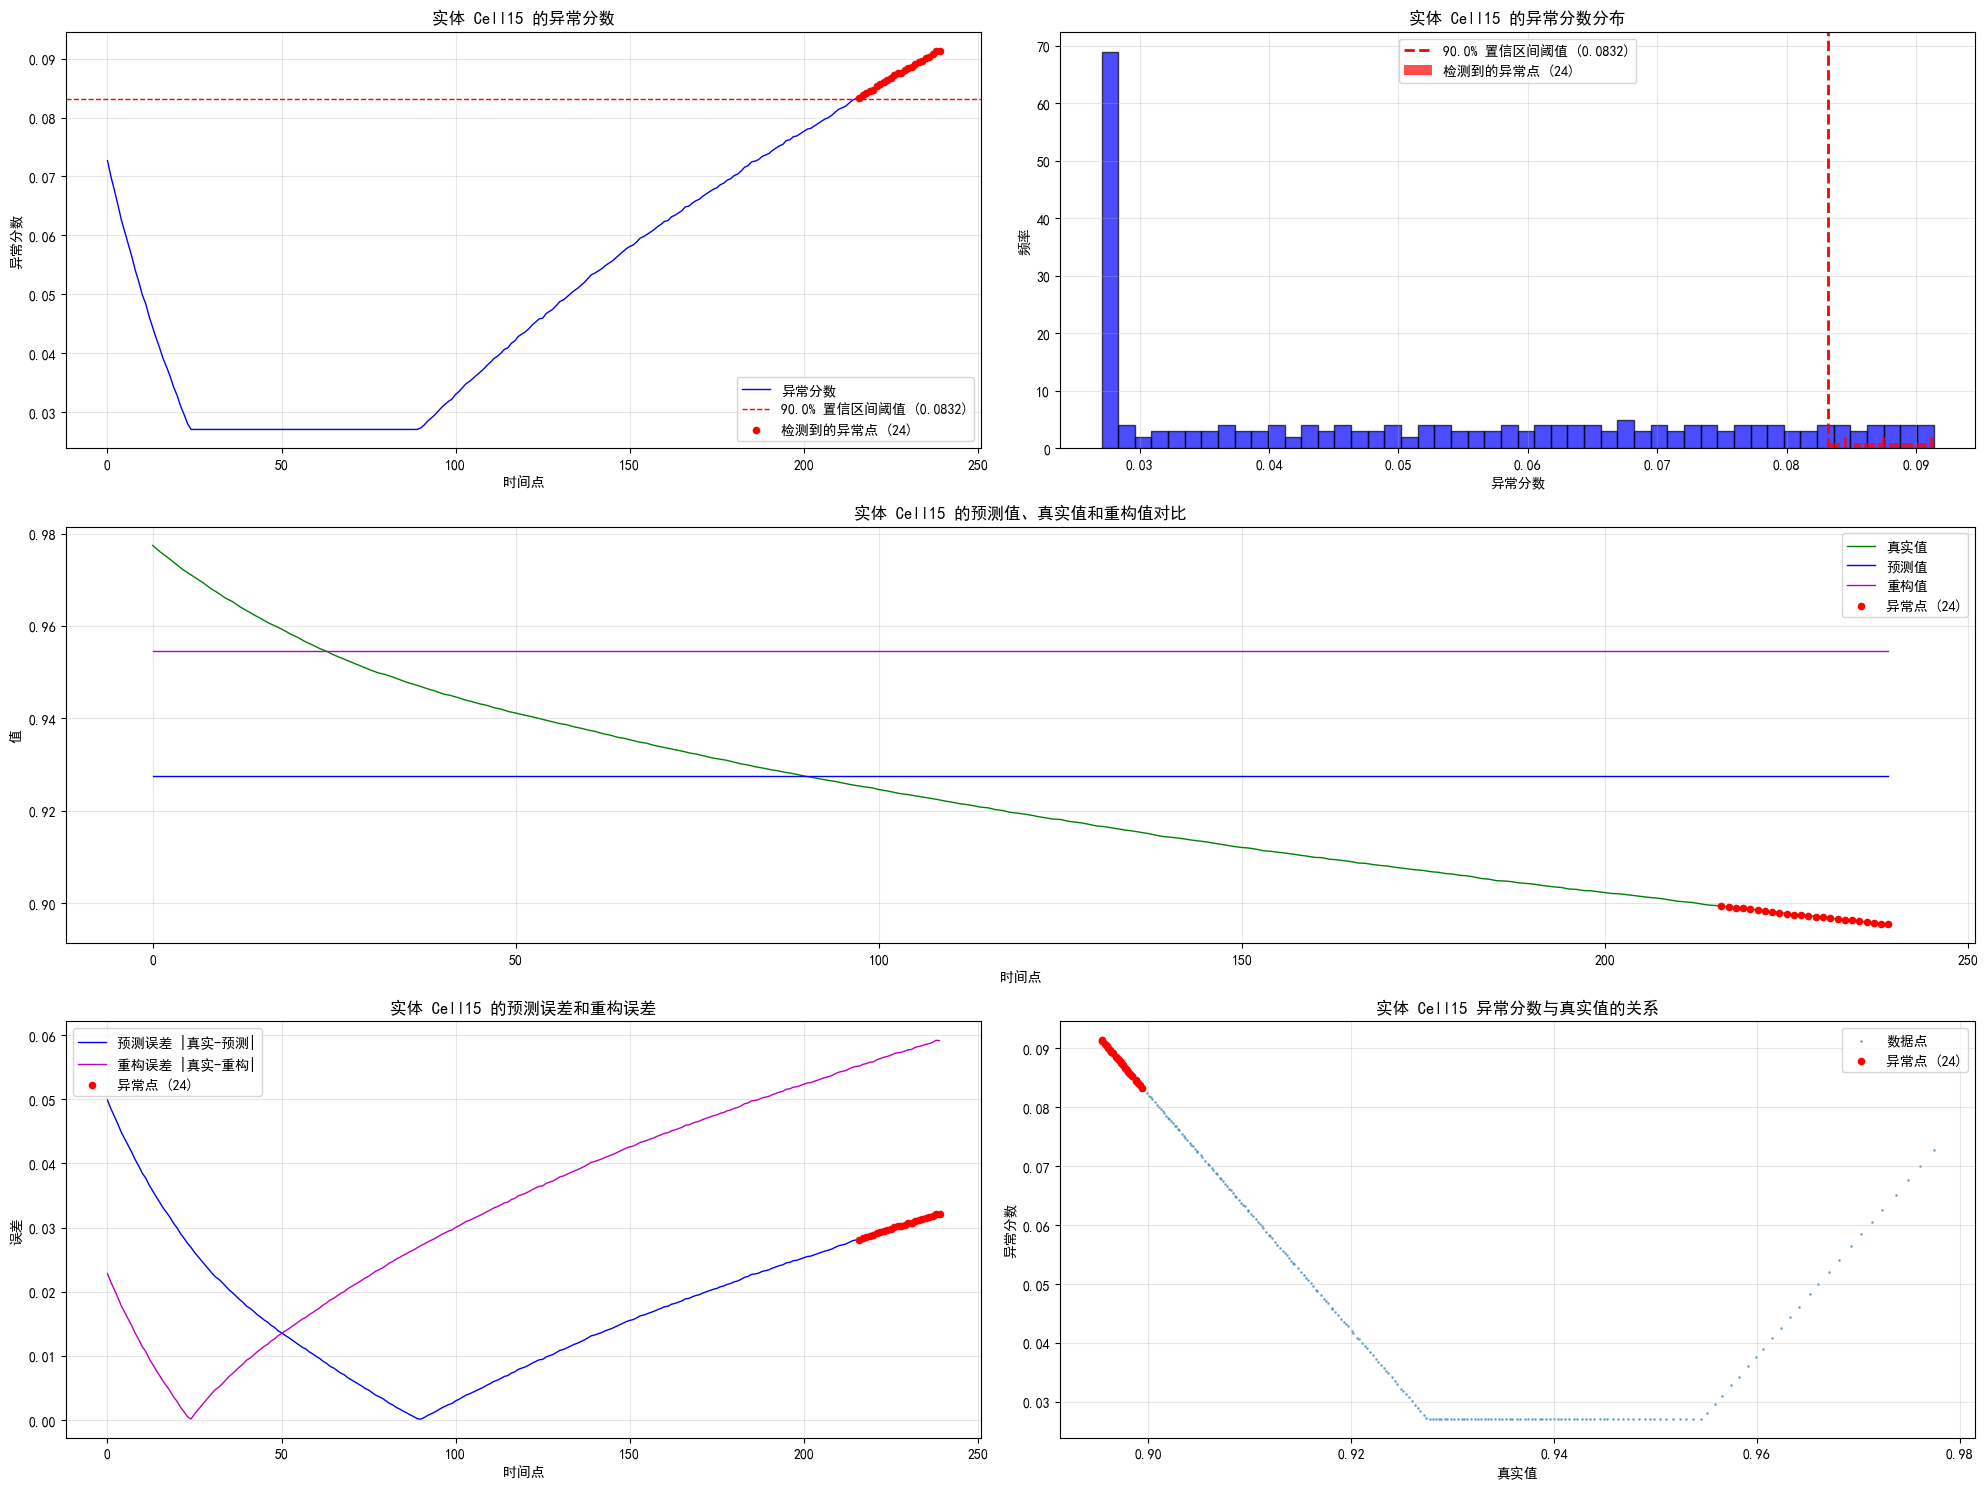


实体 Cell15 的详细分析:
----------------------------------------
前10个最高异常分数的时间点:
   1. 位置:  238, 分数: 0.091355
   2. 位置:  239, 分数: 0.091226
   3. 位置:  237, 分数: 0.090708
   4. 位置:  236, 分数: 0.090321
   5. 位置:  235, 分数: 0.090061
   6. 位置:  234, 分数: 0.089673
   7. 位置:  233, 分数: 0.089415
   8. 位置:  232, 分数: 0.089156
   9. 位置:  231, 分数: 0.088509
  10. 位置:  230, 分数: 0.088380

详细分析CALCE2测试集实体 Cell16
异常分数统计:
  最小值: 0.027060
  最大值: 0.084110
  平均值: 0.046741
  中位数: 0.042972
  标准差: 0.018957

90.0% 置信区间阈值: 0.075495
检测到的异常点数量: 24
异常点位置: [216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239]
Epsilon方法阈值: 0.092175
Epsilon方法检测到的异常点数量: 0


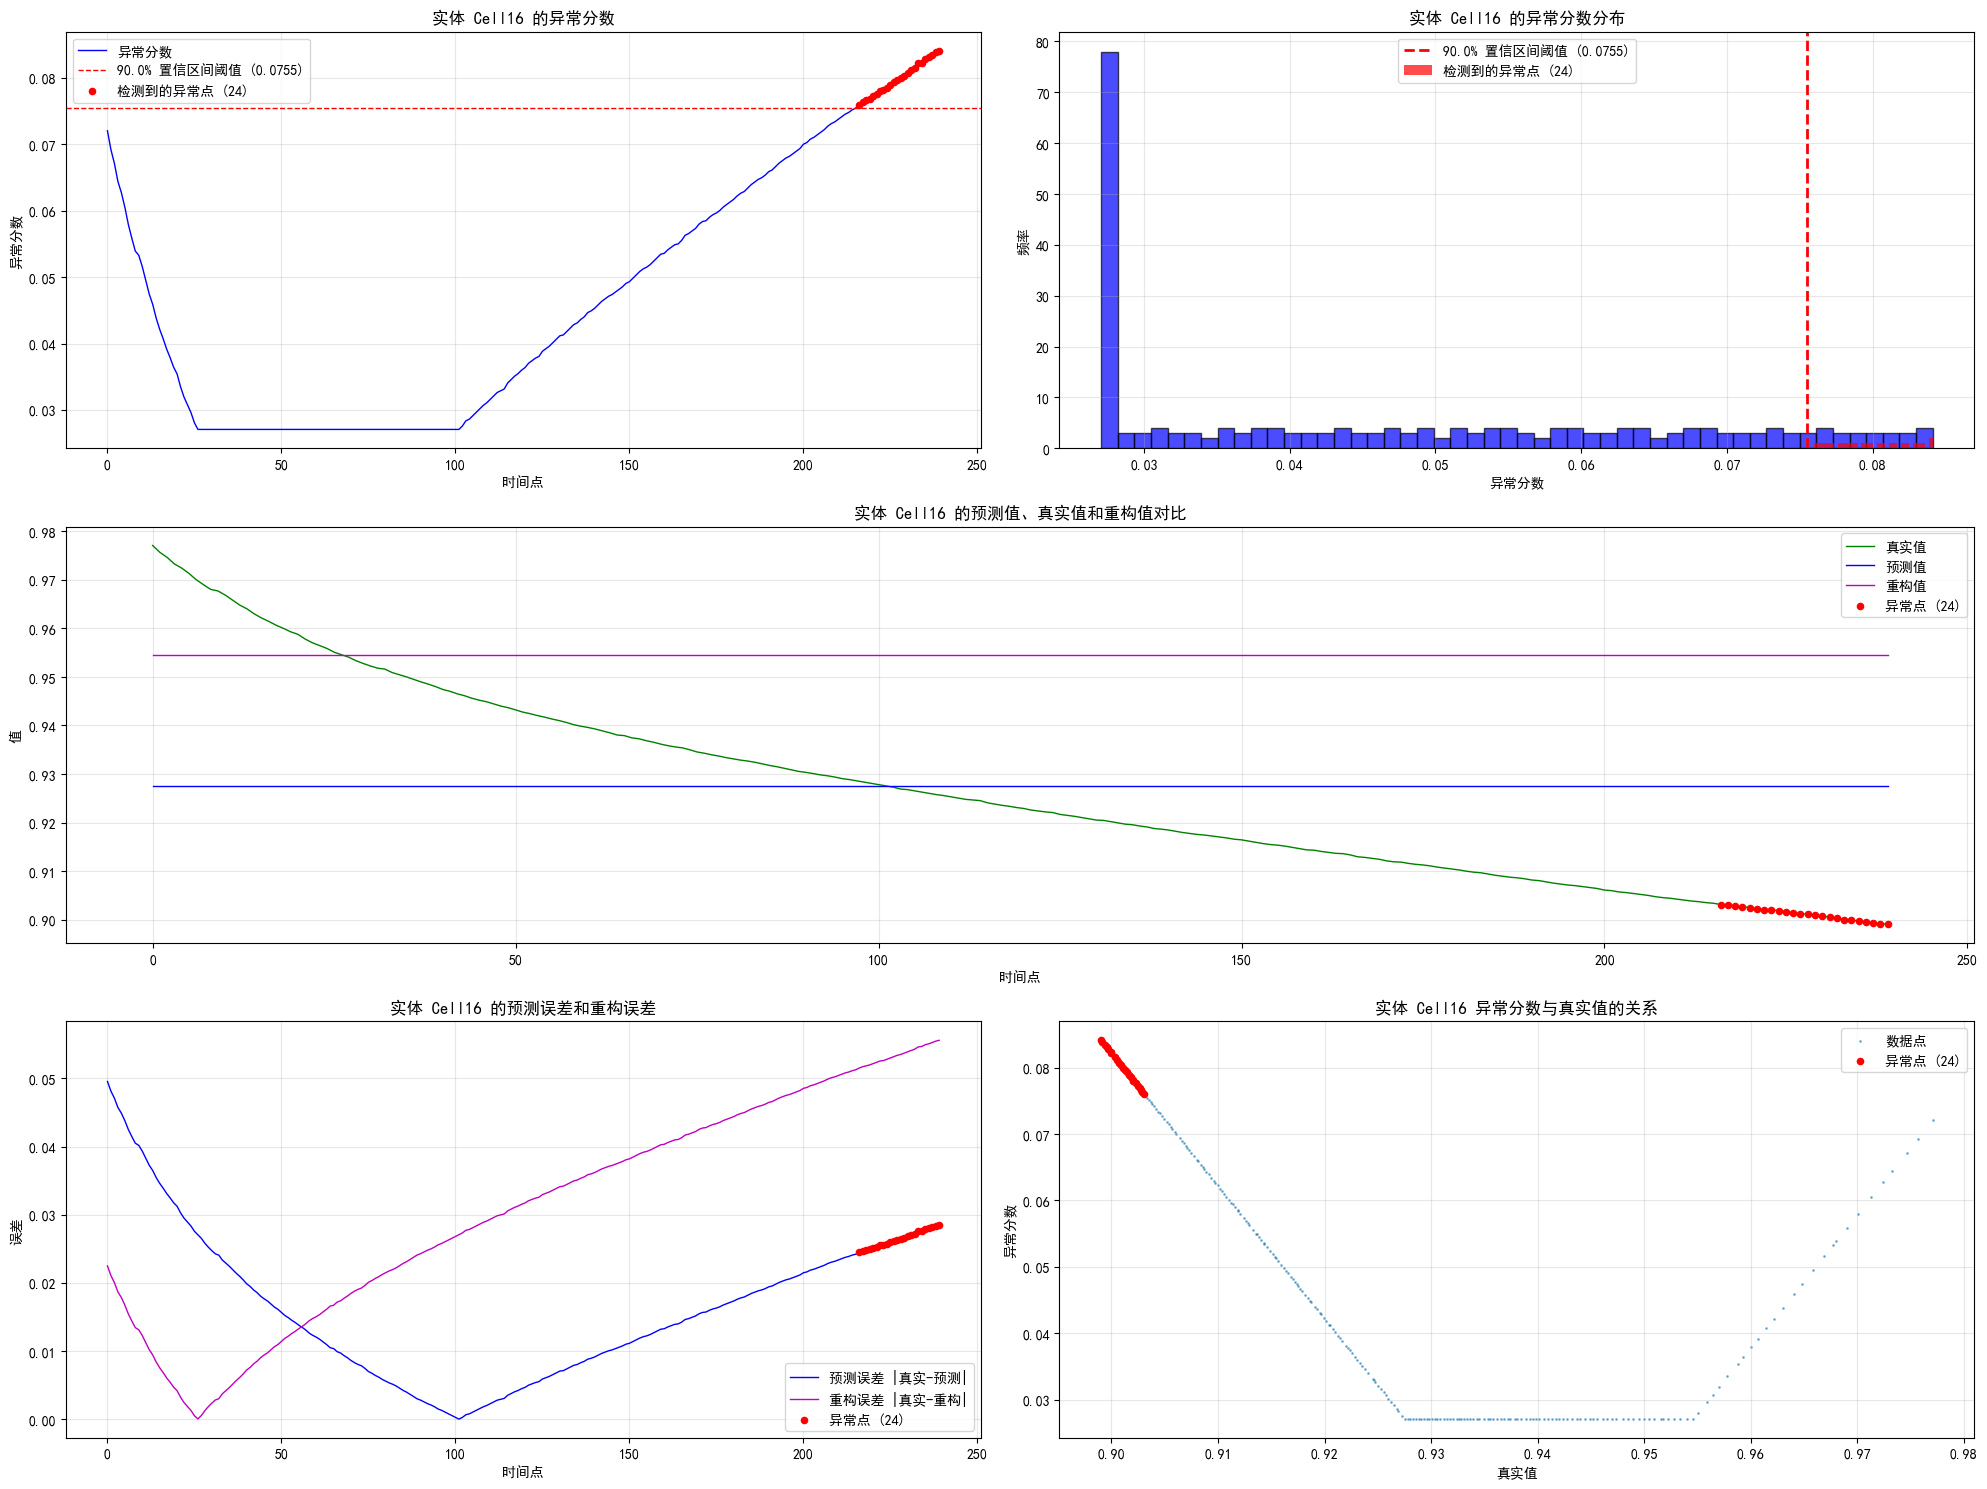


实体 Cell16 的详细分析:
----------------------------------------
前10个最高异常分数的时间点:
   1. 位置:  239, 分数: 0.084110
   2. 位置:  238, 分数: 0.083852
   3. 位置:  237, 分数: 0.083463
   4. 位置:  236, 分数: 0.083076
   5. 位置:  235, 分数: 0.082817
   6. 位置:  234, 分数: 0.082299
   7. 位置:  233, 分数: 0.082170
   8. 位置:  232, 分数: 0.081523
   9. 位置:  231, 分数: 0.081135
  10. 位置:  230, 分数: 0.080747

详细分析CALCE2测试集实体 Cell17
异常分数统计:
  最小值: 0.027060
  最大值: 0.115935
  平均值: 0.065164
  中位数: 0.063994
  标准差: 0.030201

90.0% 置信区间阈值: 0.107319
检测到的异常点数量: 24
异常点位置: [216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239]
Epsilon方法阈值: 0.092175
Epsilon方法检测到的异常点数量: 62


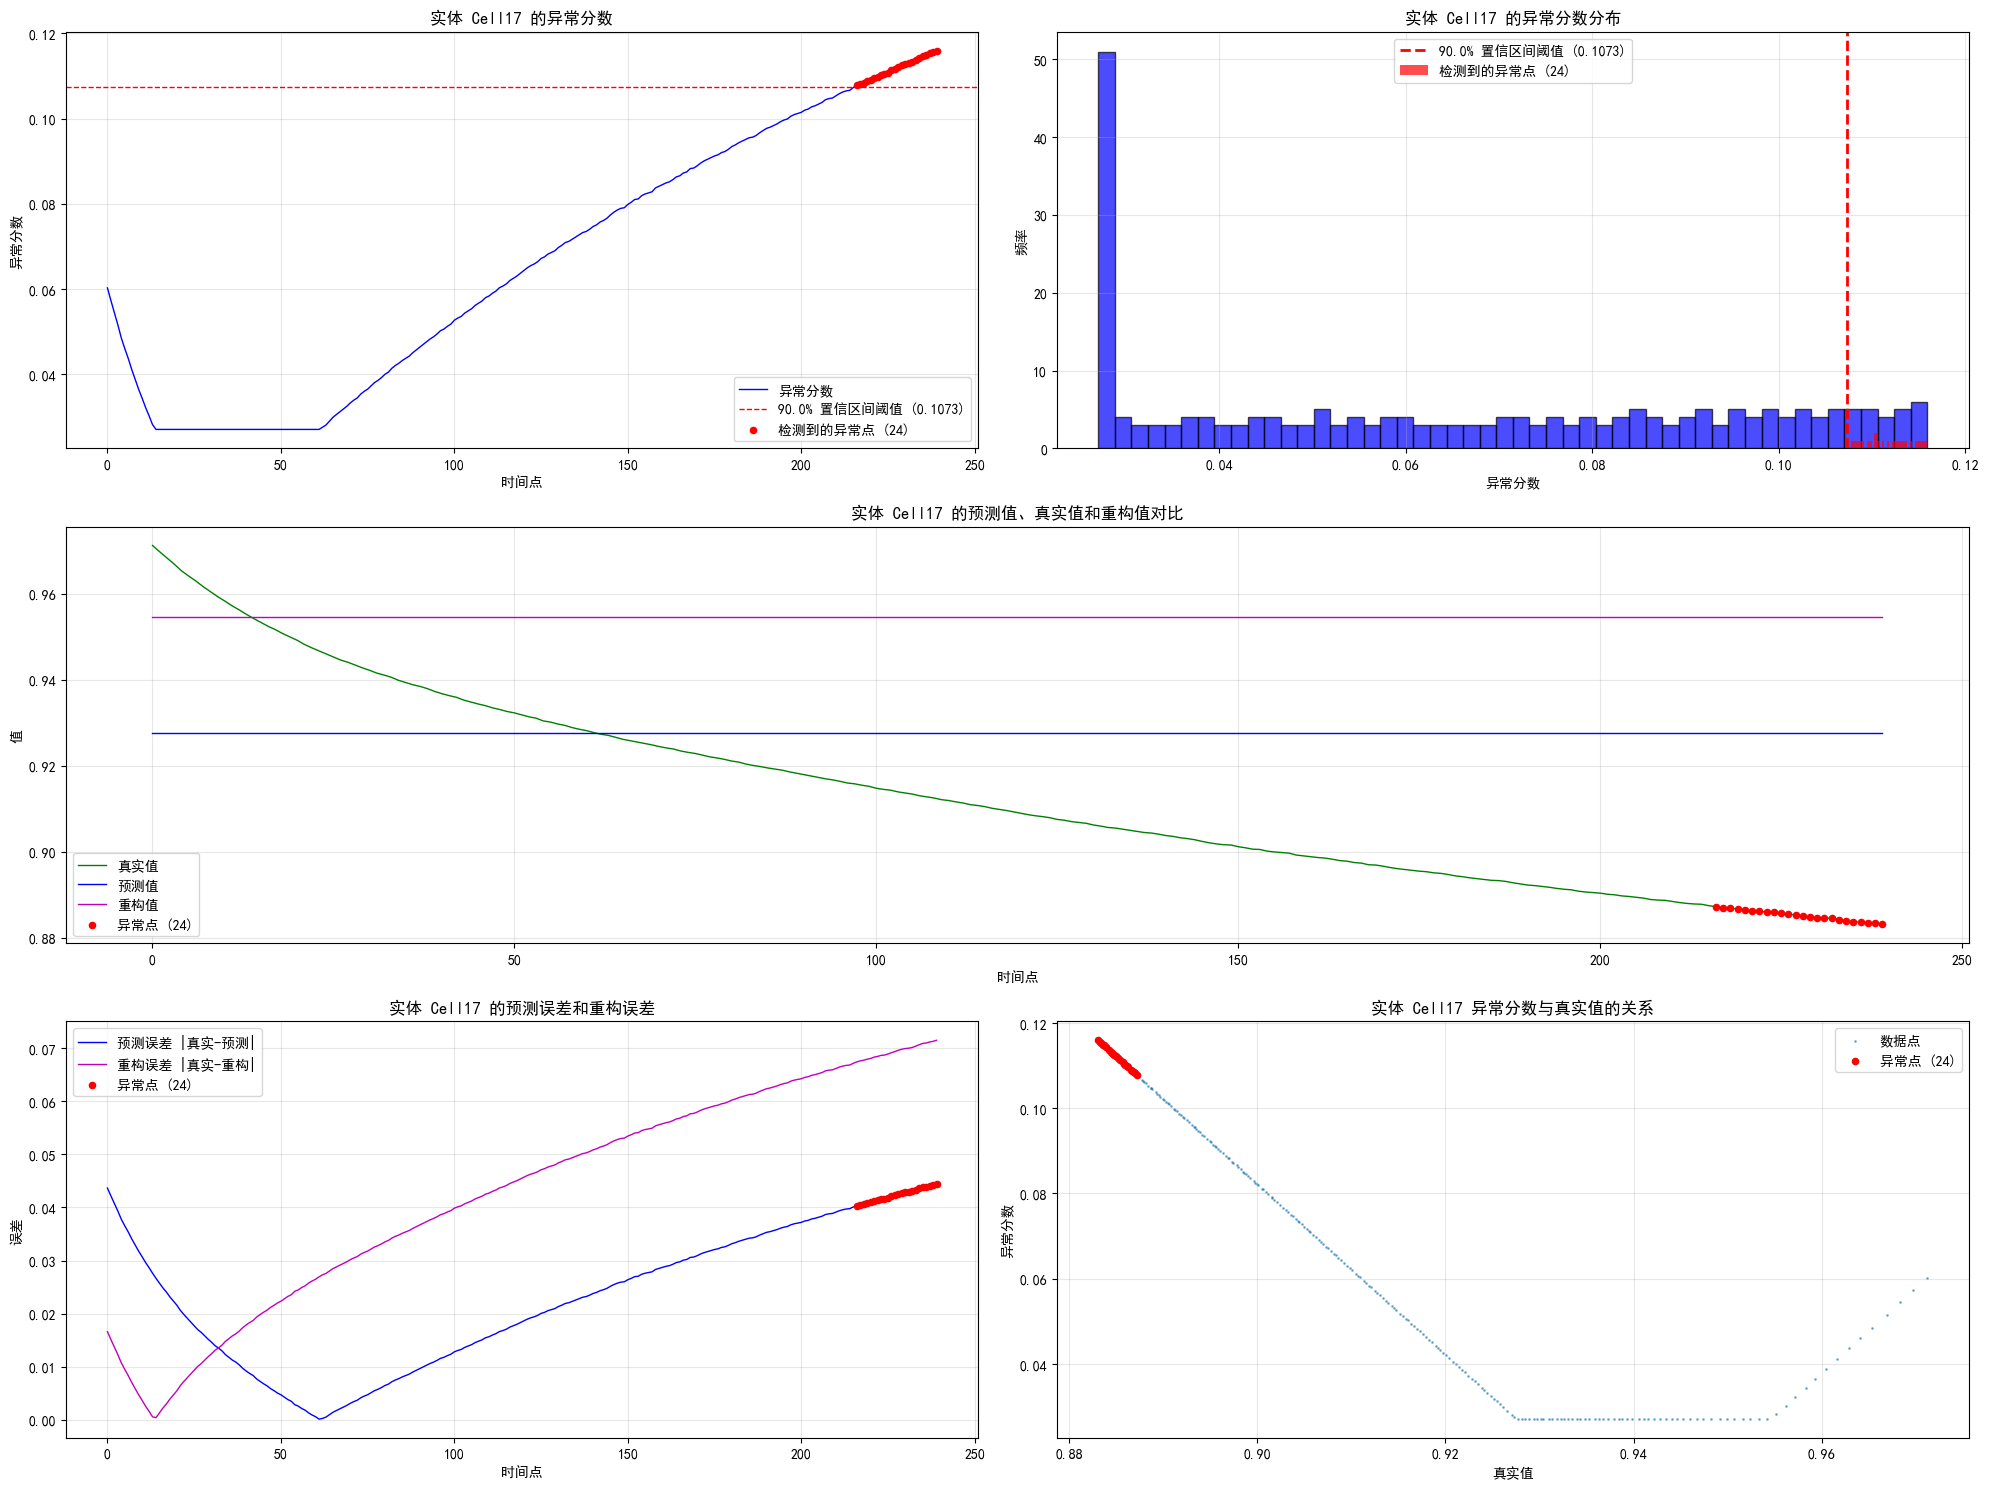


实体 Cell17 的详细分析:
----------------------------------------
前10个最高异常分数的时间点:
   1. 位置:  239, 分数: 0.115935
   2. 位置:  238, 分数: 0.115547
   3. 位置:  237, 分数: 0.115288
   4. 位置:  236, 分数: 0.114899
   5. 位置:  235, 分数: 0.114770
   6. 位置:  234, 分数: 0.114253
   7. 位置:  233, 分数: 0.113735
   8. 位置:  232, 分数: 0.113218
   9. 位置:  231, 分数: 0.112959
  10. 位置:  230, 分数: 0.112830

详细分析CALCE2测试集实体 Cell18
异常分数统计:
  最小值: 0.027060
  最大值: 0.095966
  平均值: 0.051332
  中位数: 0.048900
  标准差: 0.021535

90.0% 置信区间阈值: 0.082994
检测到的异常点数量: 24
异常点位置: [0, 1, 2, 3, 4, 5, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239]
Epsilon方法阈值: 0.092175
Epsilon方法检测到的异常点数量: 2


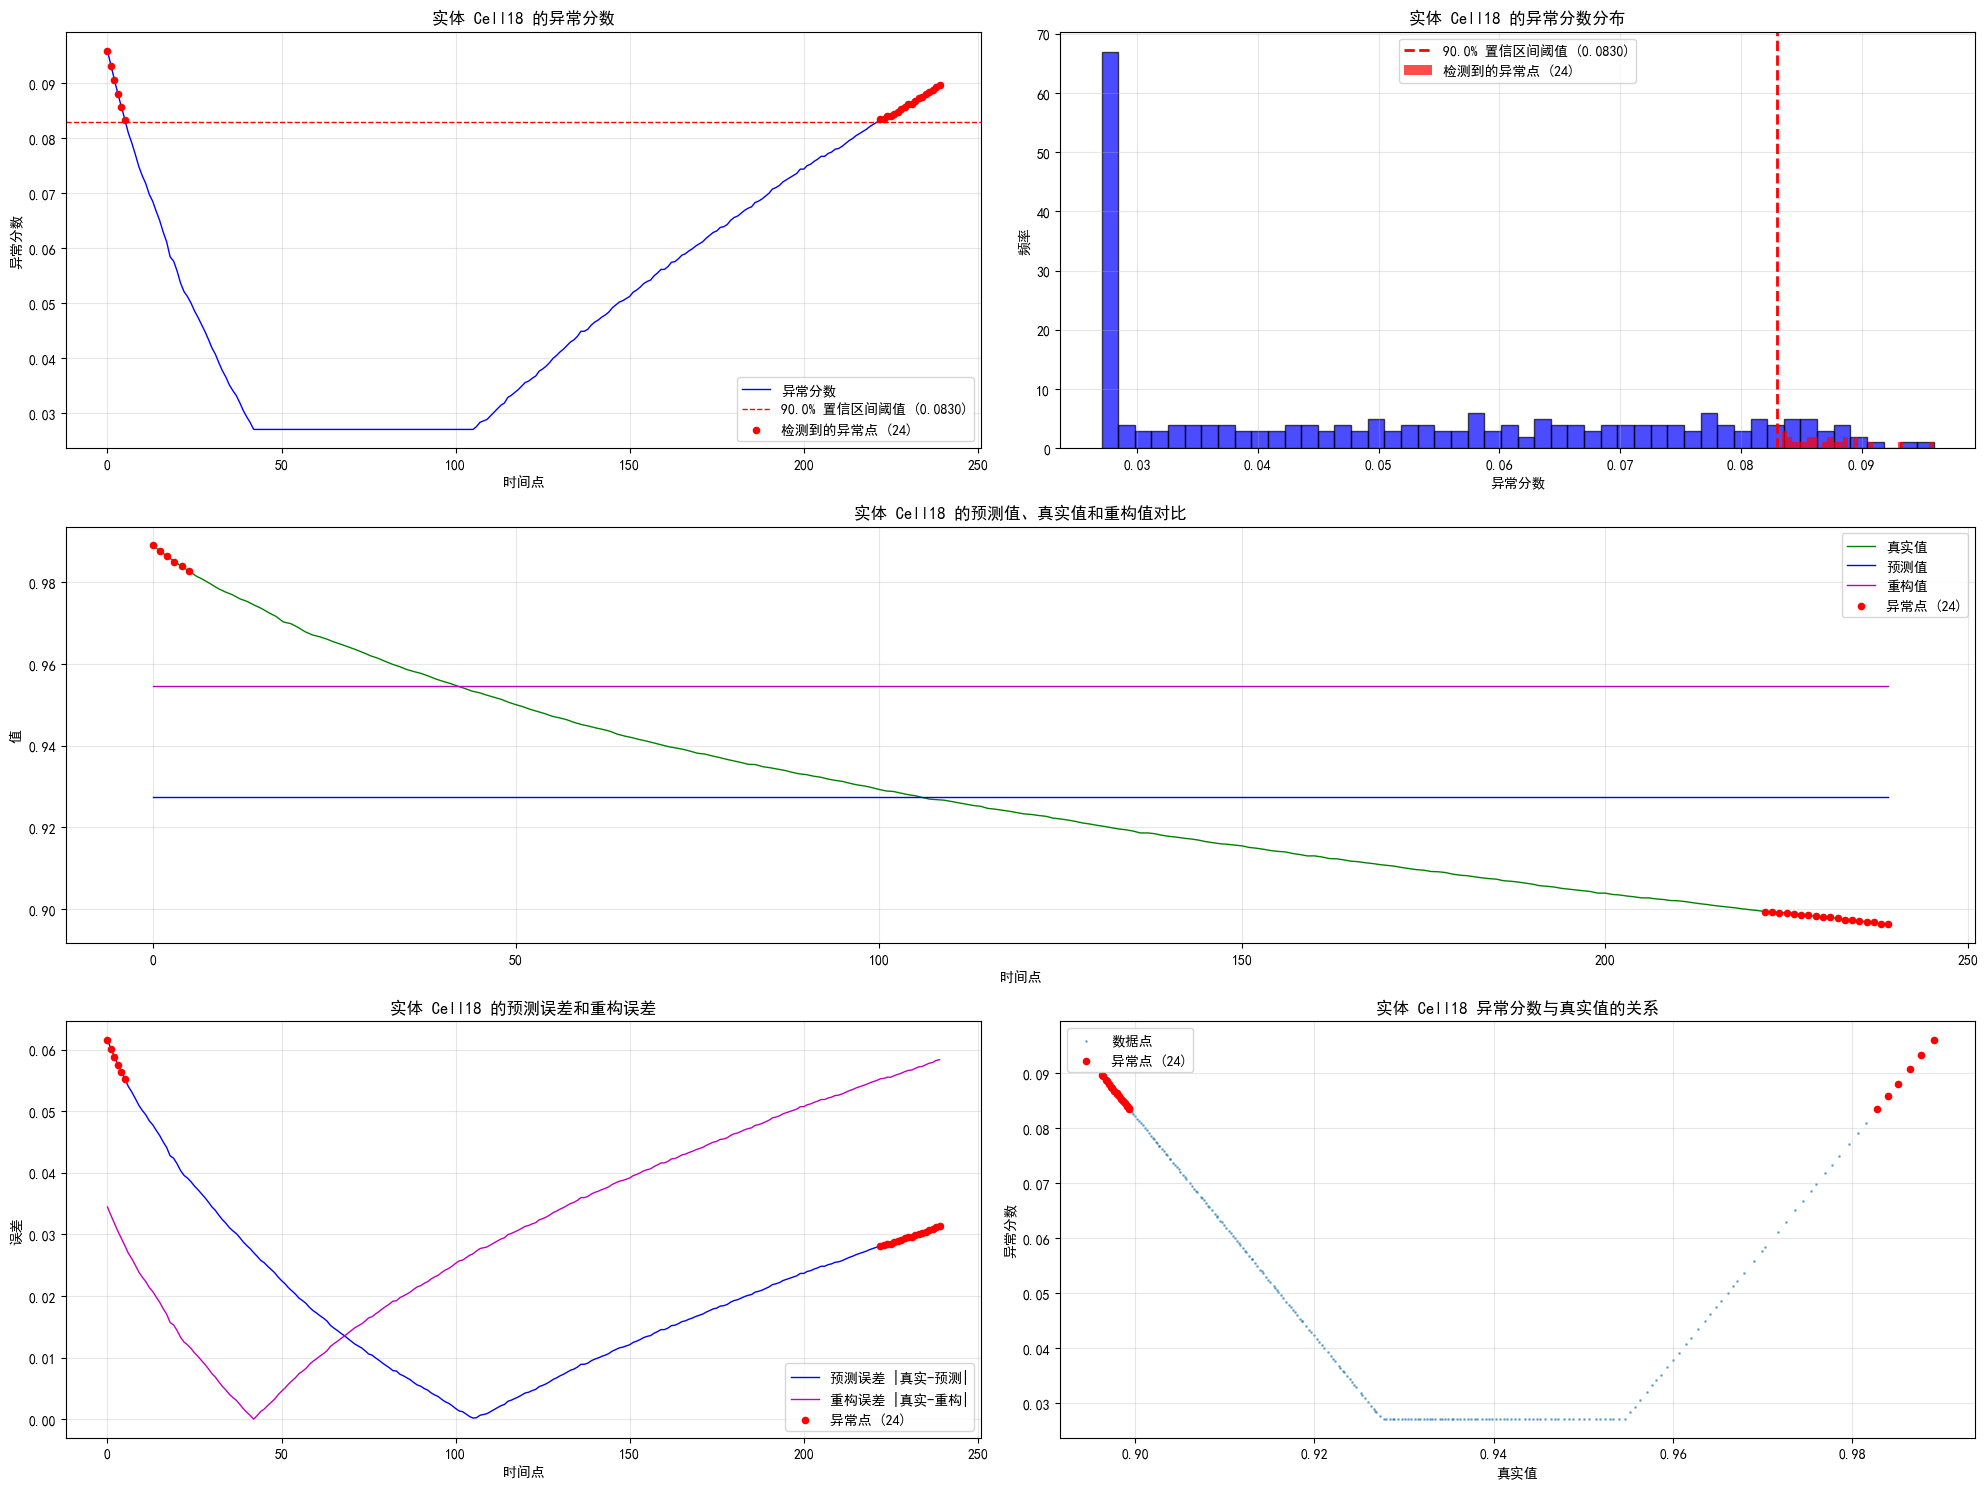


实体 Cell18 的详细分析:
----------------------------------------
前10个最高异常分数的时间点:
   1. 位置:    0, 分数: 0.095966
   2. 位置:    1, 分数: 0.093250
   3. 位置:    2, 分数: 0.090662
   4. 位置:  239, 分数: 0.089674
   5. 位置:  238, 分数: 0.089415
   6. 位置:  237, 分数: 0.088768
   7. 位置:  236, 分数: 0.088509
   8. 位置:    3, 分数: 0.088075
   9. 位置:  235, 分数: 0.087992
  10. 位置:  234, 分数: 0.087474

详细分析CALCE2测试集实体 Cell19
异常分数统计:
  最小值: 0.027060
  最大值: 0.127448
  平均值: 0.073029
  中位数: 0.074602
  标准差: 0.034101

90.0% 置信区间阈值: 0.118806
检测到的异常点数量: 24
异常点位置: [216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239]
Epsilon方法阈值: 0.092175
Epsilon方法检测到的异常点数量: 87


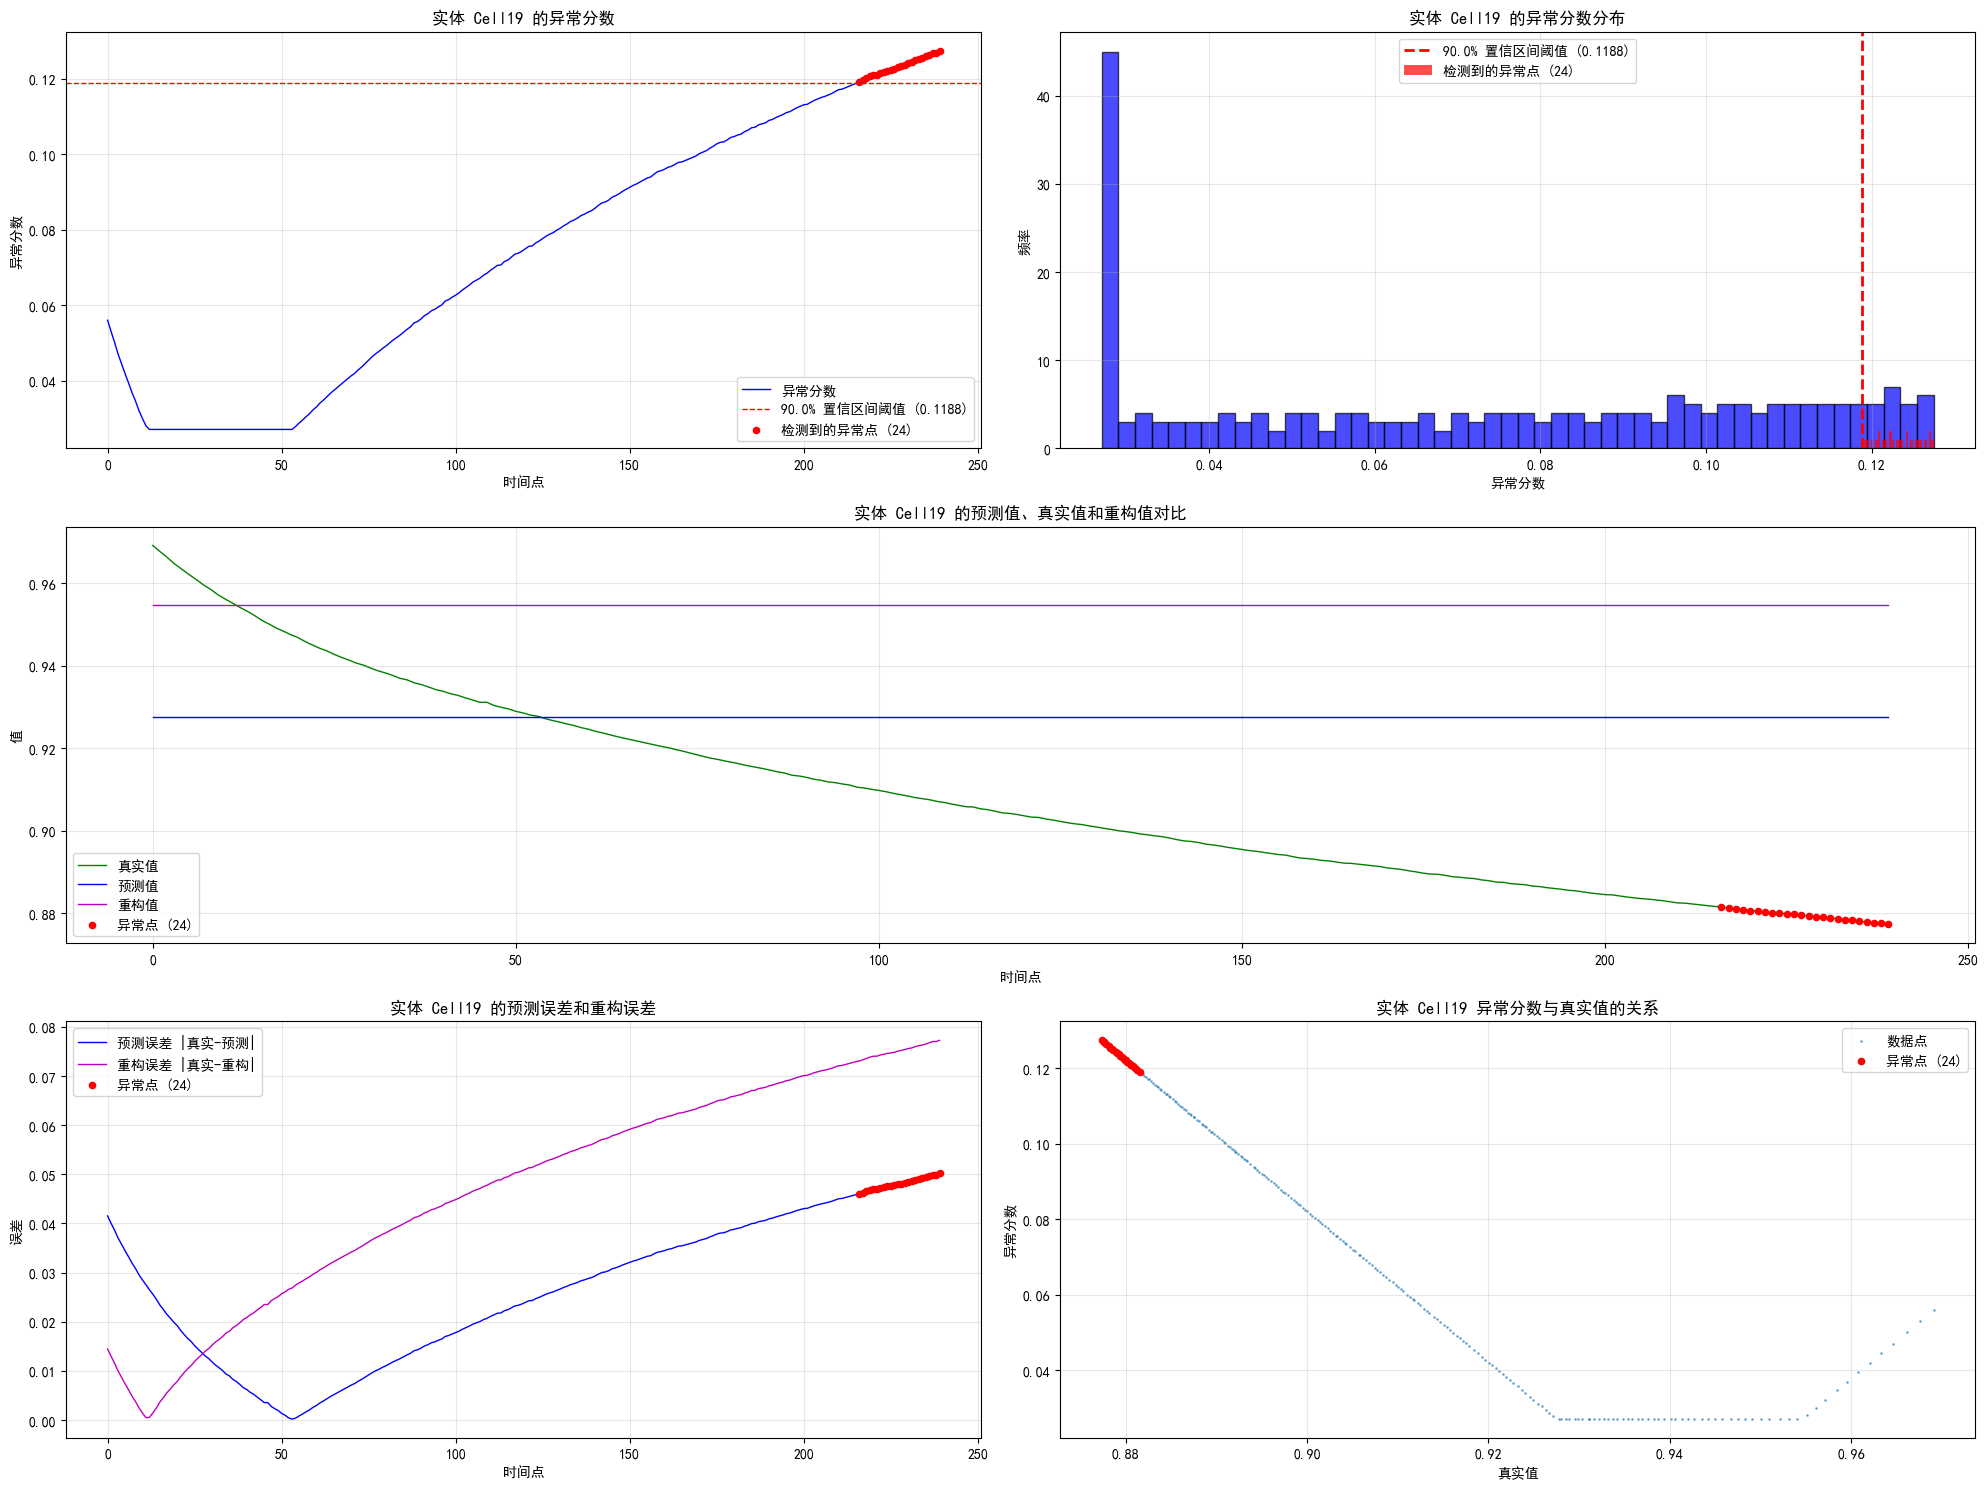


实体 Cell19 的详细分析:
----------------------------------------
前10个最高异常分数的时间点:
   1. 位置:  239, 分数: 0.127448
   2. 位置:  238, 分数: 0.126931
   3. 位置:  237, 分数: 0.126931
   4. 位置:  236, 分数: 0.126413
   5. 位置:  235, 分数: 0.125896
   6. 位置:  234, 分数: 0.125508
   7. 位置:  233, 分数: 0.125249
   8. 位置:  232, 分数: 0.124861
   9. 位置:  231, 分数: 0.124343
  10. 位置:  230, 分数: 0.124085

详细分析CALCE2测试集实体 Cell20
异常分数统计:
  最小值: 0.027060
  最大值: 0.168845
  平均值: 0.108461
  中位数: 0.119686
  标准差: 0.045717

90.0% 置信区间阈值: 0.161135
检测到的异常点数量: 24
异常点位置: [216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239]
Epsilon方法阈值: 0.092175
Epsilon方法检测到的异常点数量: 159


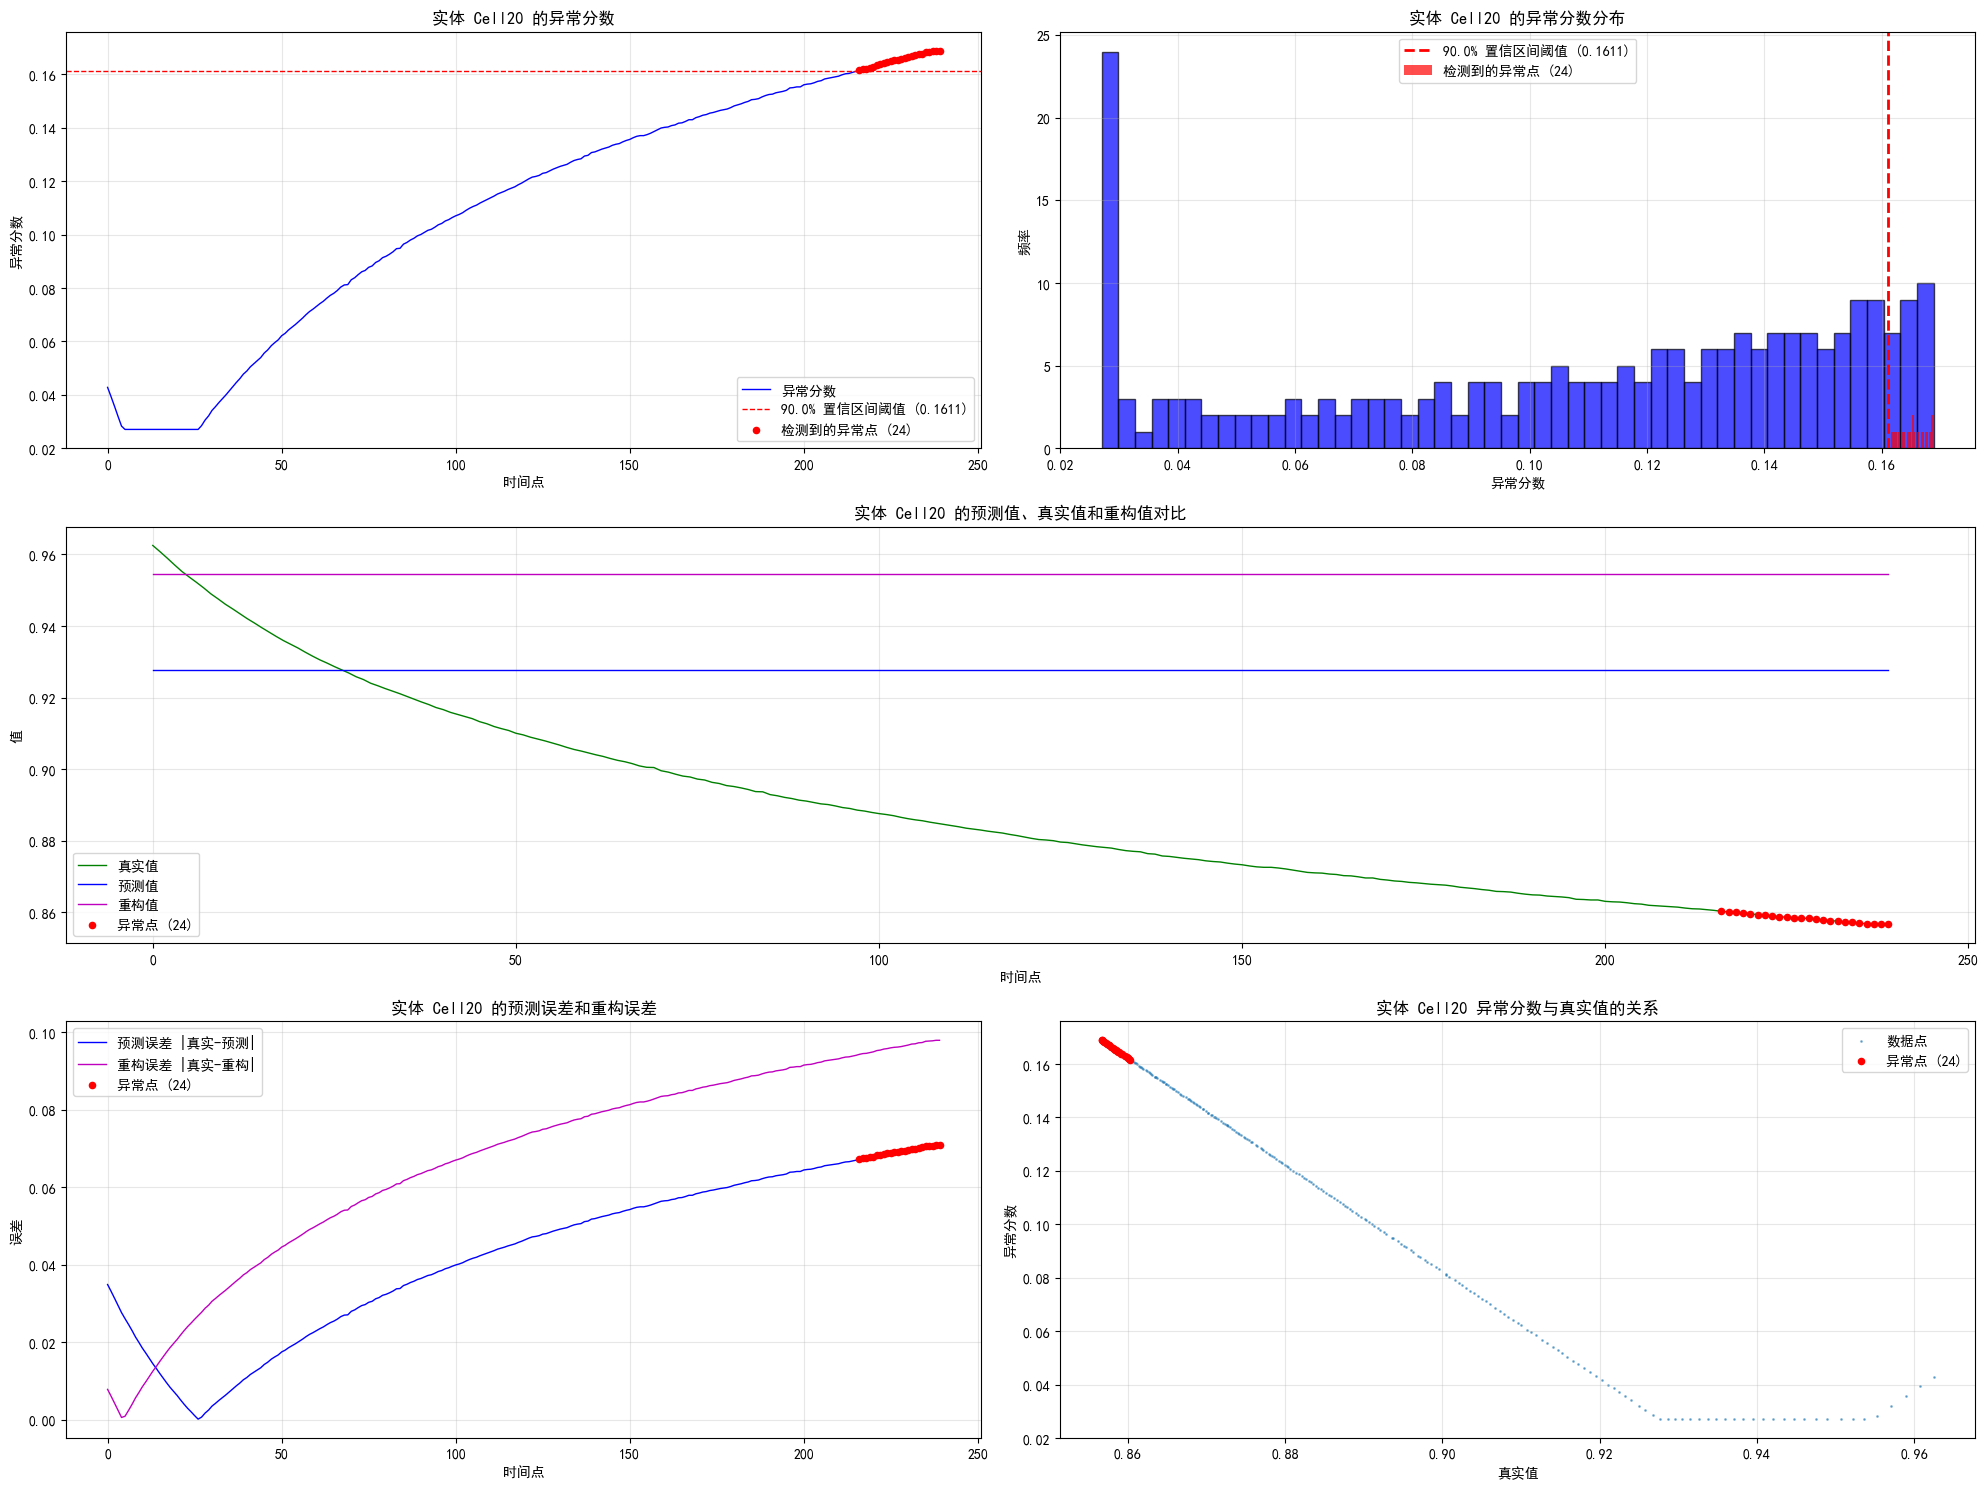


实体 Cell20 的详细分析:
----------------------------------------
前10个最高异常分数的时间点:
   1. 位置:  239, 分数: 0.168845
   2. 位置:  238, 分数: 0.168845
   3. 位置:  237, 分数: 0.168586
   4. 位置:  236, 分数: 0.168458
   5. 位置:  235, 分数: 0.168328
   6. 位置:  234, 分数: 0.167681
   7. 位置:  233, 分数: 0.167551
   8. 位置:  232, 分数: 0.167034
   9. 位置:  231, 分数: 0.166904
  10. 位置:  230, 分数: 0.166387

详细分析CALCE2测试集实体 Cell21
异常分数统计:
  最小值: 0.027060
  最大值: 0.131459
  平均值: 0.077340
  中位数: 0.080359
  标准差: 0.034424

90.0% 置信区间阈值: 0.122429
检测到的异常点数量: 24
异常点位置: [216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239]
Epsilon方法阈值: 0.092175
Epsilon方法检测到的异常点数量: 97


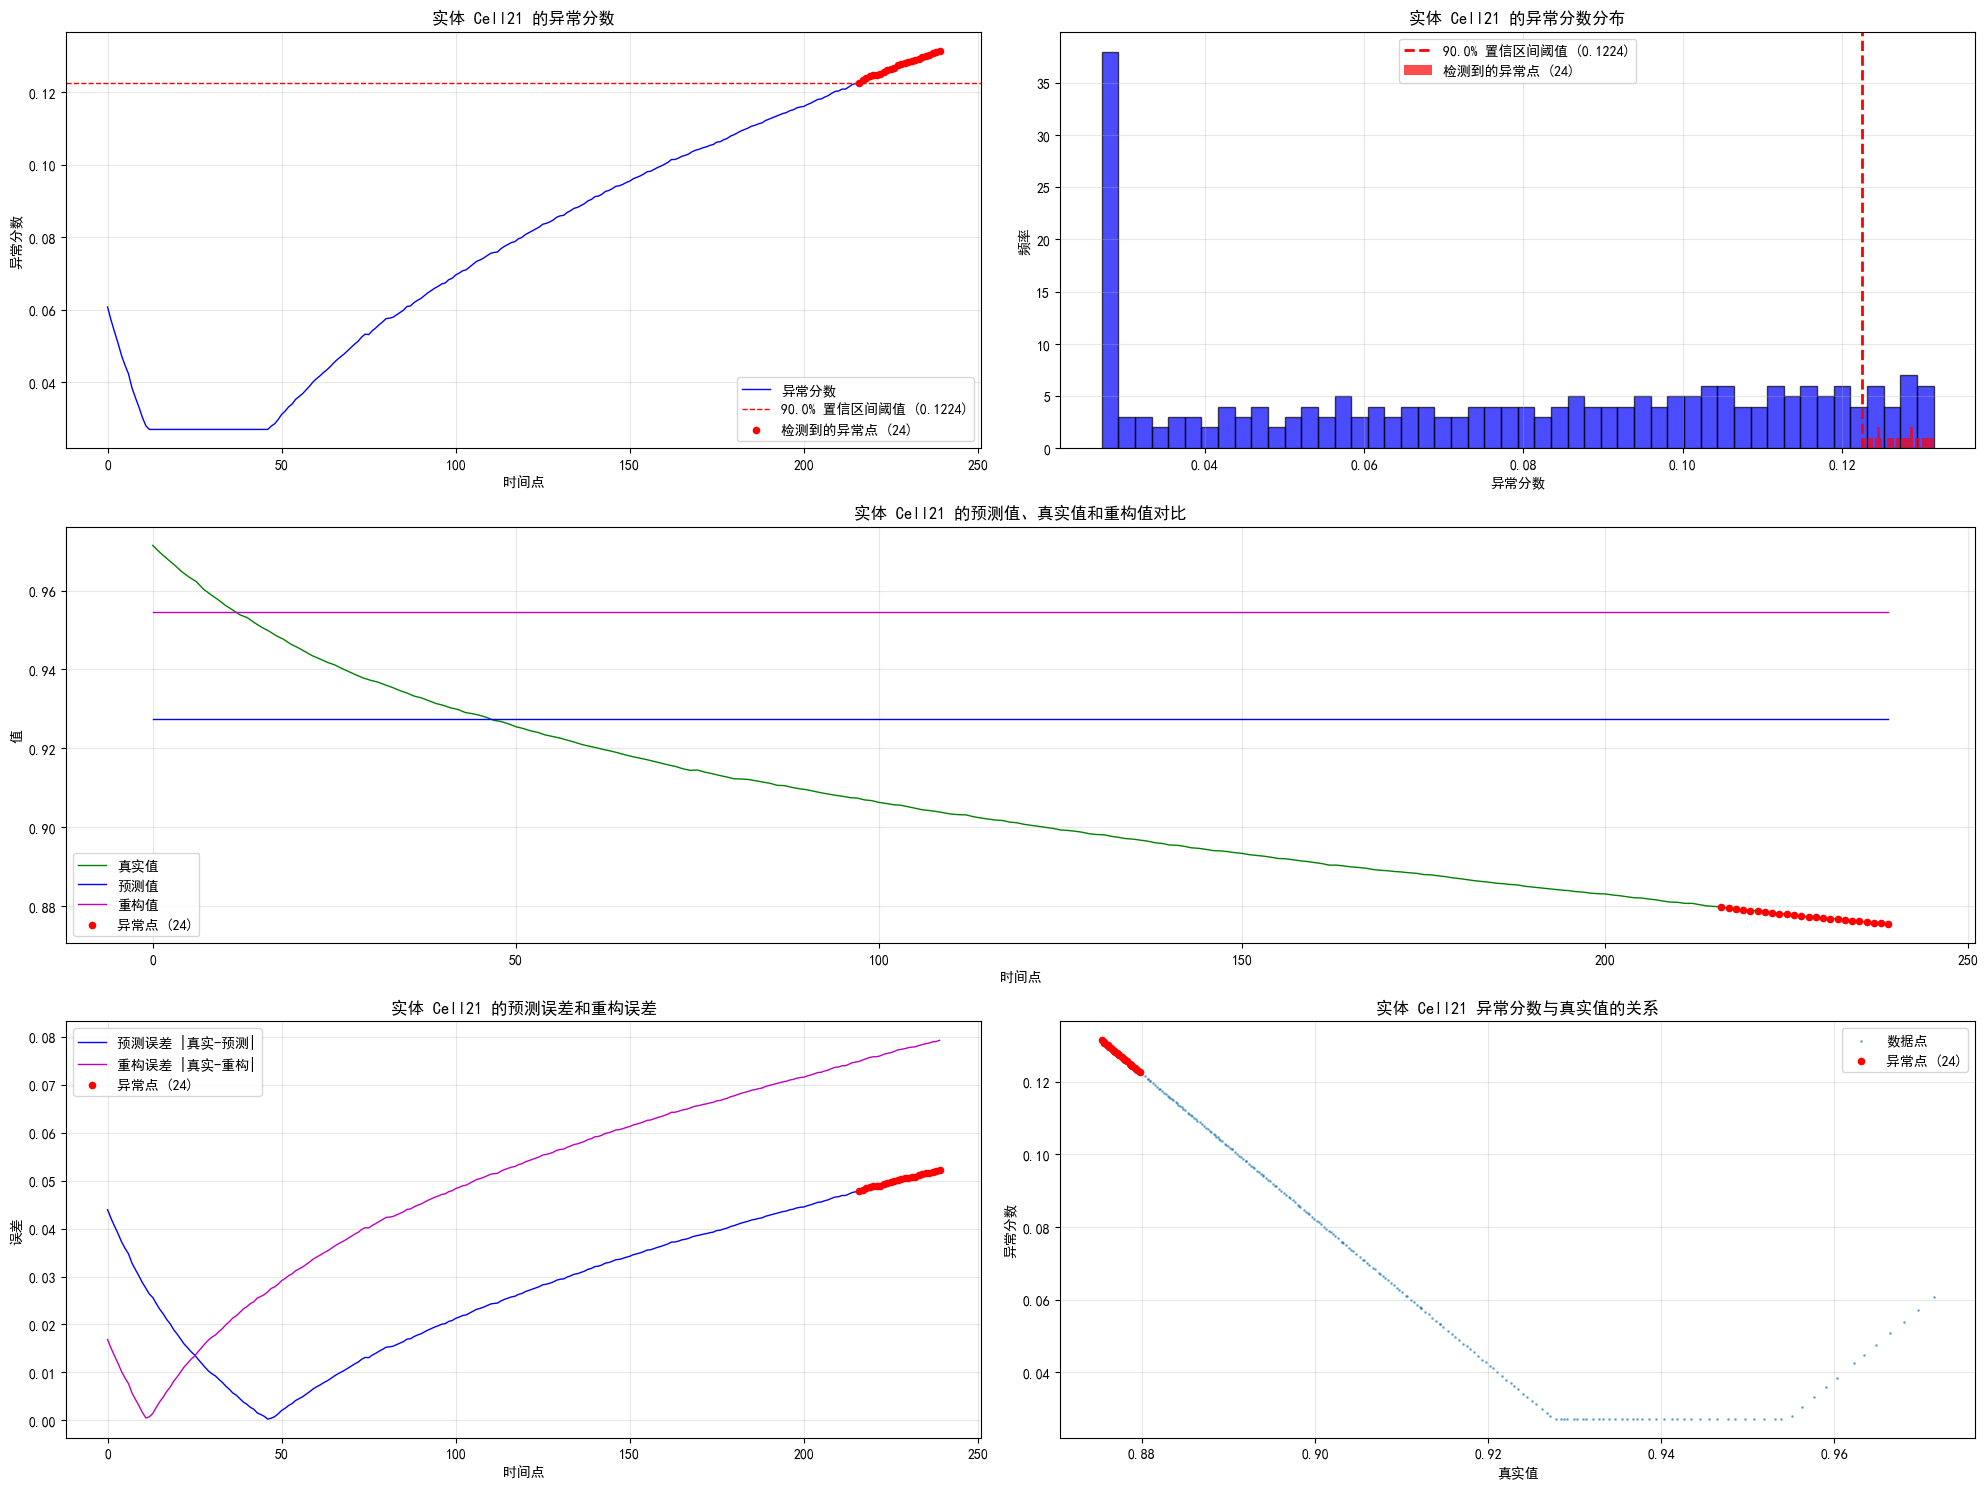


实体 Cell21 的详细分析:
----------------------------------------
前10个最高异常分数的时间点:
   1. 位置:  239, 分数: 0.131459
   2. 位置:  238, 分数: 0.130941
   3. 位置:  237, 分数: 0.130812
   4. 位置:  236, 分数: 0.130294
   5. 位置:  235, 分数: 0.130036
   6. 位置:  234, 分数: 0.129648
   7. 位置:  233, 分数: 0.129259
   8. 位置:  232, 分数: 0.128742
   9. 位置:  231, 分数: 0.128612
  10. 位置:  230, 分数: 0.128354

详细分析CALCE2测试集实体 Cell22
异常分数统计:
  最小值: 0.027060
  最大值: 0.079666
  平均值: 0.038784
  中位数: 0.033140
  标准差: 0.013471

90.0% 置信区间阈值: 0.059583
检测到的异常点数量: 24
异常点位置: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239]
Epsilon方法阈值: 0.092175
Epsilon方法检测到的异常点数量: 0


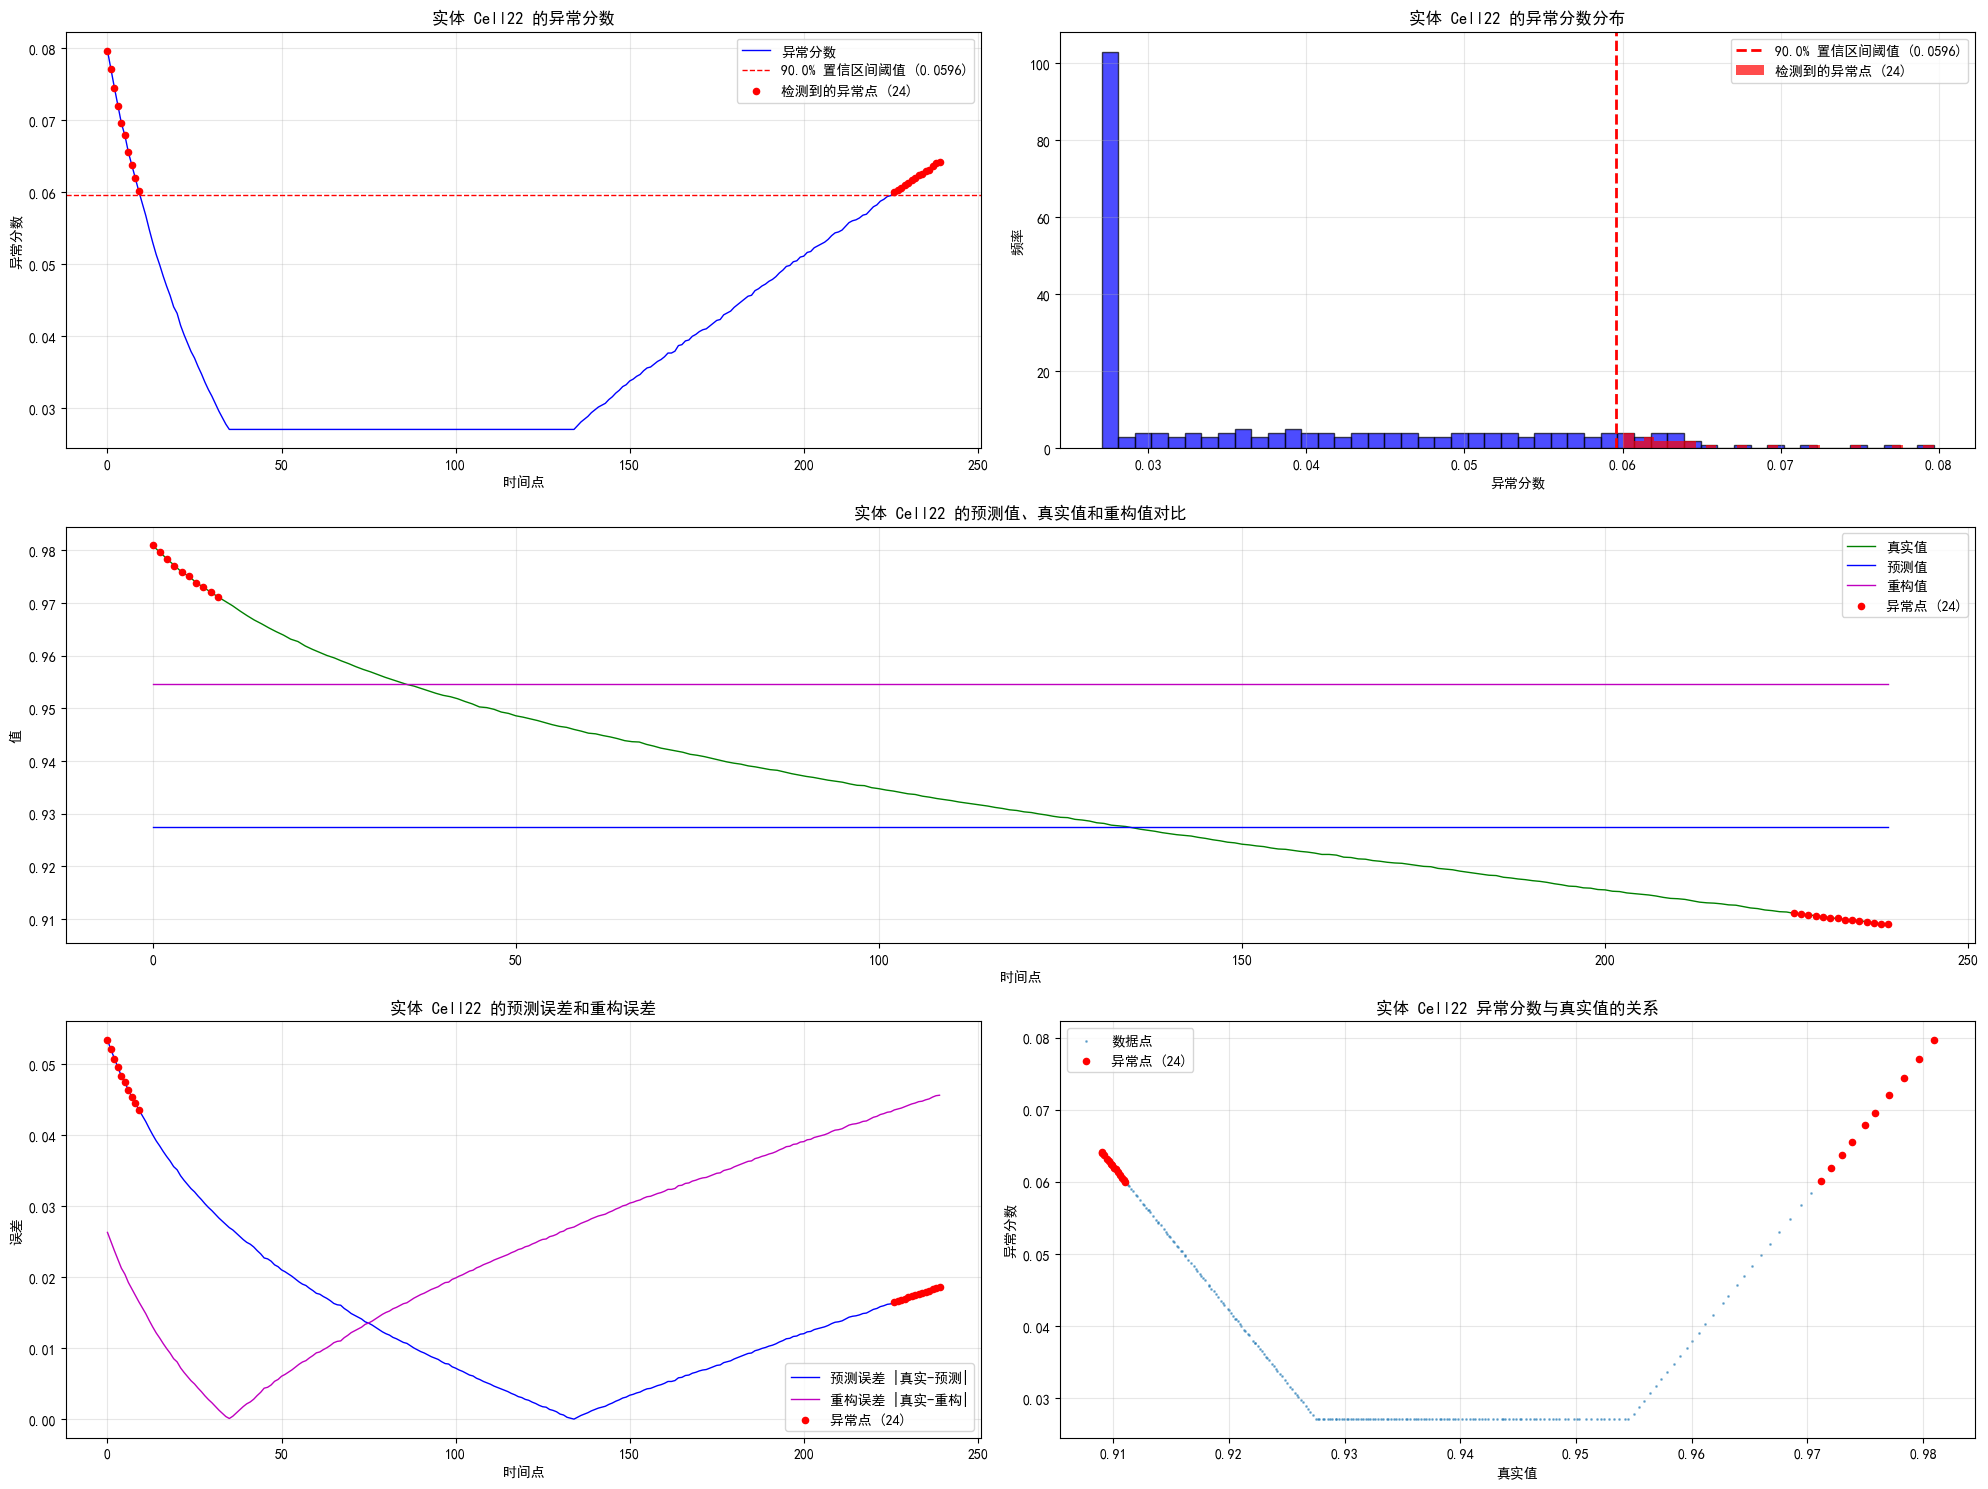


实体 Cell22 的详细分析:
----------------------------------------
前10个最高异常分数的时间点:
   1. 位置:    0, 分数: 0.079666
   2. 位置:    1, 分数: 0.077079
   3. 位置:    2, 分数: 0.074491
   4. 位置:    3, 分数: 0.072034
   5. 位置:    4, 分数: 0.069576
   6. 位置:    5, 分数: 0.067894
   7. 位置:    6, 分数: 0.065565
   8. 位置:  239, 分数: 0.064188
   9. 位置:  238, 分数: 0.064059
  10. 位置:    7, 分数: 0.063754

详细分析CALCE2测试集实体 Cell23
异常分数统计:
  最小值: 0.027060
  最大值: 0.083464
  平均值: 0.047400
  中位数: 0.044008
  标准差: 0.019115

90.0% 置信区间阈值: 0.075598
检测到的异常点数量: 24
异常点位置: [0, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239]
Epsilon方法阈值: 0.092175
Epsilon方法检测到的异常点数量: 0


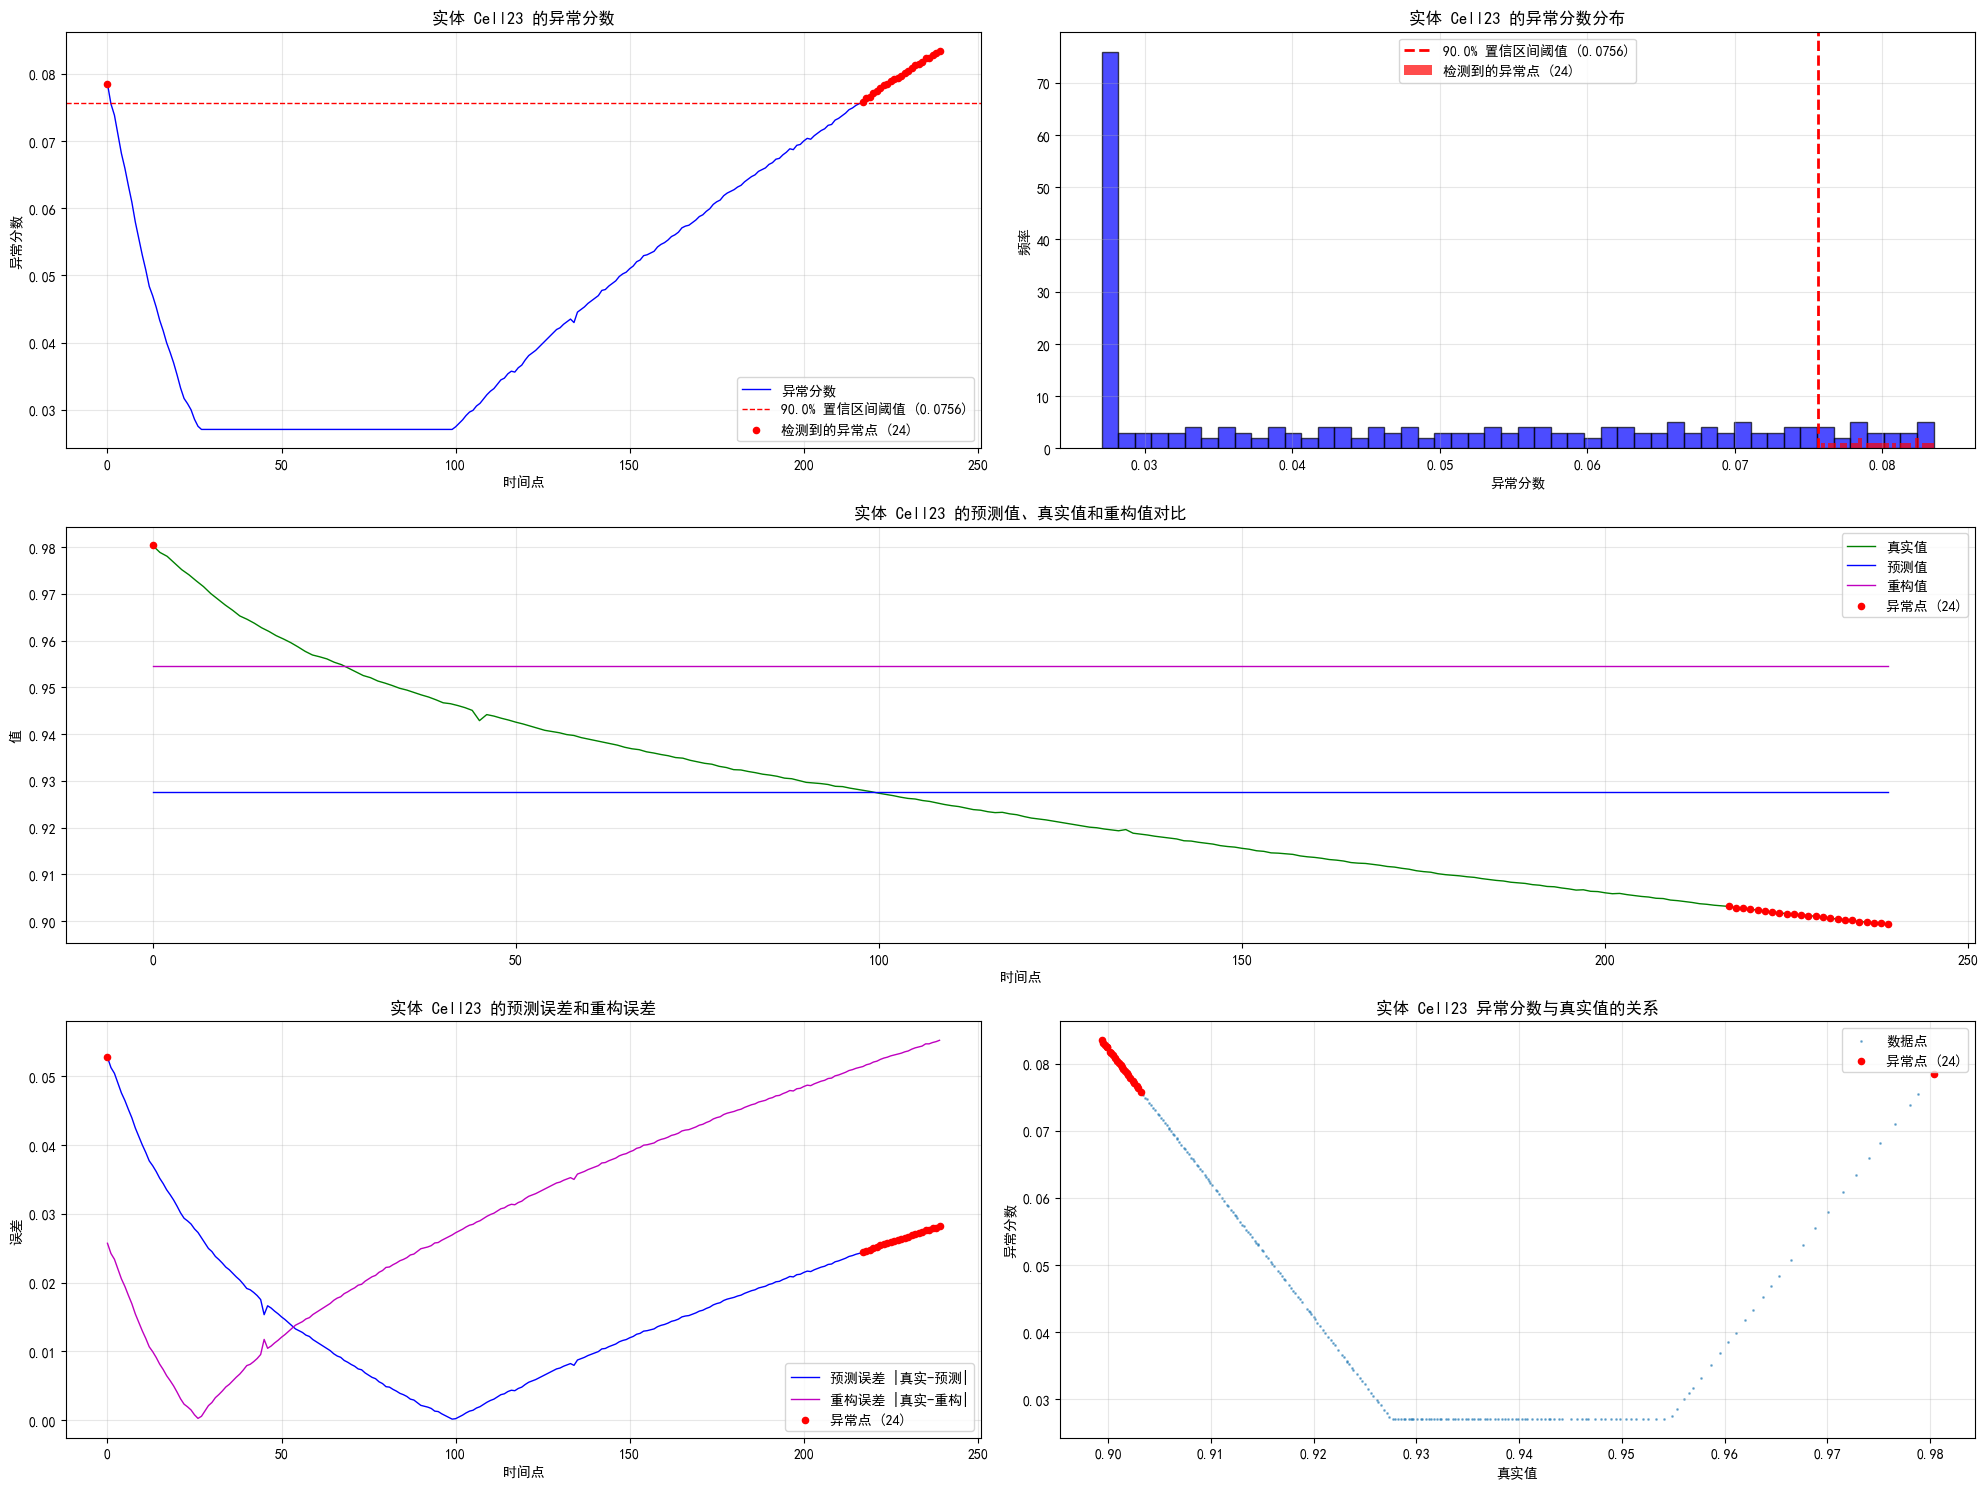


实体 Cell23 的详细分析:
----------------------------------------
前10个最高异常分数的时间点:
   1. 位置:  239, 分数: 0.083464
   2. 位置:  238, 分数: 0.083075
   3. 位置:  237, 分数: 0.082817
   4. 位置:  236, 分数: 0.082429
   5. 位置:  235, 分数: 0.082429
   6. 位置:  234, 分数: 0.081782
   7. 位置:  233, 分数: 0.081523
   8. 位置:  232, 分数: 0.081264
   9. 位置:  231, 分数: 0.080877
  10. 位置:  230, 分数: 0.080359


In [14]:
# 使用示例
# 分析CALCE数据集
result_path = './output/CALCE2'
print(f"分析路径: {result_path}")

# 详细分析异常检测结果
detailed_analysis(result_path, confidence_level=0.9)

# 如果需要分析CALCE2数据集，可以使用以下代码:
# result_path2 = './output/CALCE2'
# print(f"\n分析路径: {result_path2}")
# detailed_analysis(result_path2, confidence_level=0.95)
